In [1]:
import time
import matplotlib.pyplot as plt
from IPython import display
def hold(circuit, state, counts, fig1, fig2, fig3):
    circuit.draw(output='mpl', fold=100, ax=fig1.gca())
    plot_state_qsphere(state, ax=fig2.gca())
    plot_histogram(counts, ax=fig3.gca())
    display.display(fig1)
    display.display(fig2)
    display.display(fig3)
    display.clear_output(wait=True)
    time.sleep(2)



In [2]:
import matplotlib.pyplot as plt
import numpy as np
from qiskit.visualization import plot_state_qsphere, plot_histogram
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector


from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, DensityMatrix, Operator
from qiskit.circuit.library import Diagonal

n = 4  # numero di qubit
steps = int(np.sqrt(2**n))


# Stato di marcatura
mark_state = Statevector.from_label('1100')

# Operatore di diffusione
diffuse_operator = 2 * DensityMatrix.from_label(n * '0') - Operator.from_label(n * 'I')

# Circuito di marcatura che induce una fase -1 sul mark_state
mark_circuit = QuantumCircuit(n)
mark_circuit.append(Diagonal((-1)**mark_state.data), range(n))
mark_circuit.name = 'Mark'  # Nome descrittivo del circuito

# Circuito di diffusione che riflette intorno all'averaging = 2|0><0| - I
diffuse_circuit = QuantumCircuit(n)
diffuse_circuit.append(Diagonal(diffuse_operator.data.diagonal()), range(n))
diffuse_circuit.name = 'Diffuse'  # Nome descrittivo del circuito


In [3]:
# A single Grover's step: encode + reflect
mark_and_diffuse = QuantumCircuit(n)
all_qubits = mark_and_diffuse.qubits
mark_and_diffuse.append(mark_circuit, all_qubits)#matk
mark_and_diffuse.h(all_qubits)
mark_and_diffuse.append(diffuse_circuit, all_qubits)#diffuse
mark_and_diffuse.h(all_qubits)
print(mark_and_diffuse)

     ┌───────┐┌───┐┌──────────┐┌───┐
q_0: ┤0      ├┤ H ├┤0         ├┤ H ├
     │       │├───┤│          │├───┤
q_1: ┤1      ├┤ H ├┤1         ├┤ H ├
     │  Mark │├───┤│  Diffuse │├───┤
q_2: ┤2      ├┤ H ├┤2         ├┤ H ├
     │       │├───┤│          │├───┤
q_3: ┤3      ├┤ H ├┤3         ├┤ H ├
     └───────┘└───┘└──────────┘└───┘


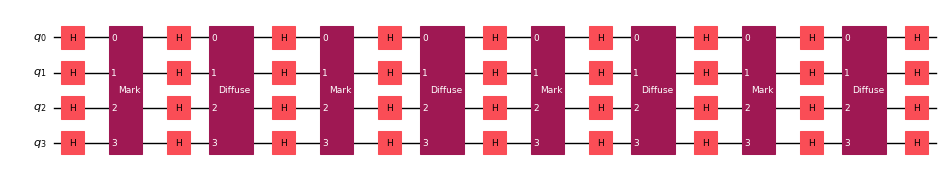

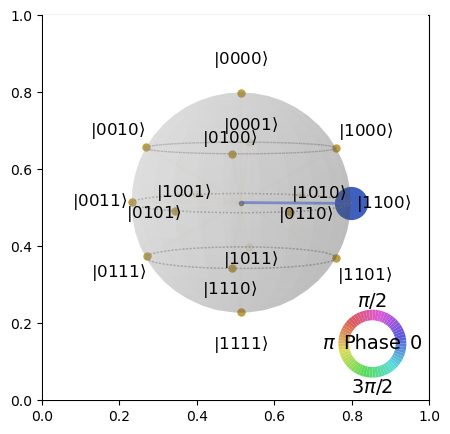

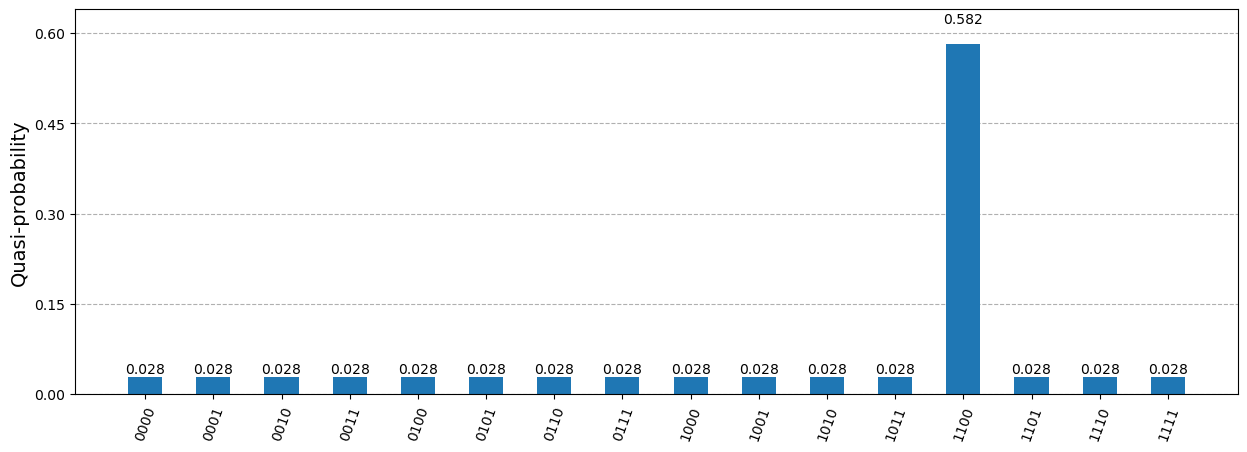

In [5]:
# Draw and update 3 figures: circuit, state, probabilities
fig1 = plt.figure(figsize=(12,5))
fig2 = plt.figure(figsize=(5,5))
fig3 = plt.figure(figsize=(15,5))

# Build and analyze incrementally
grover_circuit = QuantumCircuit(n)
all_qubits = grover_circuit.qubits

# First layer: Prepare uniform superposition
grover_circuit.h(all_qubits)
state = Statevector.from_label('+' * len(all_qubits))

# Keep iterating to amplify the correct amplitude
for step in range(steps):
    # visualize circuit, state, probabilities
    #hold(grover_circuit, state.data, state.probabilities_dict(), fig1, fig2, fig3)

    # step circuit
    grover_circuit = grover_circuit.compose(mark_and_diffuse)

    # step state
    state = state.evolve(mark_and_diffuse)
    
hold(grover_circuit, state.data, state.probabilities_dict(), fig1, fig2, fig3)
